In [2]:
import pandas as pd  # Para manejo de datos
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive  # Para acceder a archivos en Google Drive

drive.mount('/content/drive')  # Montar Google Drive en Colab

ruta_archivo = '/content/drive/MyDrive/Proyecto_Analitica/caso2_delvalle.csv'  # Ruta del archivo CSV
df = pd.read_csv(ruta_archivo)  # Cargar dataset desde el archivo CSV

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Hola

In [3]:
# Exploración técnica inicial del dataset
print("--- Dimensiones del dataset ---")  # Mostrar las dimensiones del DataFrame
print(df.shape)

print("\n--- Tipos de datos por columna ---")  # Mostrar los tipos de datos de cada columna
print(df.dtypes)

print("\n--- Resumen de valores nulos ---")  # Mostrar el resumen de valores nulos por columna
print(df.isnull().sum())

--- Dimensiones del dataset ---
(900, 18)

--- Tipos de datos por columna ---
cliente_id                   object
rut_cliente                  object
segmento                     object
region                       object
vendedor_id                  object
antiguedad_meses              int64
frecuencia_pedidos_mes        int64
monto_promedio_pedido         int64
dias_sin_comprar              int64
fecha_ultimo_pedido          object
tasa_devolucion             float64
causa_ultima_devolucion      object
tasa_cumplimiento_pedido    float64
distancia_km                  int64
descuento_informal            int64
pct_descuento_aplicado      float64
saldo_deuda_clp               int64
abandono                      int64
dtype: object

--- Resumen de valores nulos ---
cliente_id                    0
rut_cliente                   0
segmento                      0
region                        0
vendedor_id                   0
antiguedad_meses              0
frecuencia_pedidos_mes        0
mo

In [4]:
# Análisis de la variable objetivo 'abandono'
if 'abandono' in df.columns:
    print("\n--- Analisis de la variable objetivo 'abandono' ---")  # Verificar la existencia de la columna 'abandono'

    valores_unicos = df['abandono'].unique()  # Obtener los valores únicos de la columna 'abandono'
    print("Valores unicos de la variable:", valores_unicos)  # Mostrar los valores únicos

    tipo_dato = df['abandono'].dtype  # Obtener el tipo de dato de la columna 'abandono'
    print("Tipo de dato de la variable:", tipo_dato)  # Mostrar el tipo de dato

    if set(valores_unicos).issubset({0, 1}):
        print("El formato cumple con los requerimientos: la variable es binaria (0 y 1).")  # Verificar si la variable es binaria
    else:
        print("Atencion: la variable no es estrictamente binaria o contiene valores inesperados.")  # Mostrar advertencia si la variable no es binaria

else:
    print("Error: la variable 'abandono' no se encuentra en el dataset cargado.")  # Mostrar error si la columna 'abandono' no existe


--- Analisis de la variable objetivo 'abandono' ---
Valores unicos de la variable: [0 1]
Tipo de dato de la variable: int64
El formato cumple con los requerimientos: la variable es binaria (0 y 1).


In [5]:
# Tratamiento de valores nulos y duplicados
from pandas.api.types import is_numeric_dtype

# Identificación de valores nulos
print("\n--- Identificación de valores nulos ---")  # Mostrar la cantidad de valores nulos por columna
null_counts = df.isnull().sum()
print(null_counts)

if null_counts.sum() > 0:
    # Tratar valores nulos (por ejemplo, reemplazar con la media o mediana)
    print("\n--- Tratamiento de valores nulos ---")  # Mostrar el proceso de tratamiento de valores nulos
    for col in null_counts.index:
        if is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(df[col].mean())  # Rellenar valores nulos numéricos con la media
        else:
            df[col] = df[col].fillna(df[col].mode()[0])  # Rellenar valores nulos categóricos con la moda

# Identificación de valores duplicados
print("\n--- Identificación de valores duplicados ---")  # Mostrar la cantidad de valores duplicados
duplicate_counts = df.duplicated().sum()
print(duplicate_counts)

if duplicate_counts > 0:
    # Eliminar duplicados
    print("\n--- Eliminación de valores duplicados ---")  # Mostrar el proceso de eliminación de duplicados
    df.drop_duplicates(inplace=True)  # Eliminar filas duplicadas


--- Identificación de valores nulos ---
cliente_id                    0
rut_cliente                   0
segmento                      0
region                        0
vendedor_id                   0
antiguedad_meses              0
frecuencia_pedidos_mes        0
monto_promedio_pedido         0
dias_sin_comprar              0
fecha_ultimo_pedido           0
tasa_devolucion               0
causa_ultima_devolucion     201
tasa_cumplimiento_pedido      0
distancia_km                  0
descuento_informal            0
pct_descuento_aplicado        0
saldo_deuda_clp               0
abandono                      0
dtype: int64

--- Tratamiento de valores nulos ---

--- Identificación de valores duplicados ---
0


Total de columnas numéricas: 10


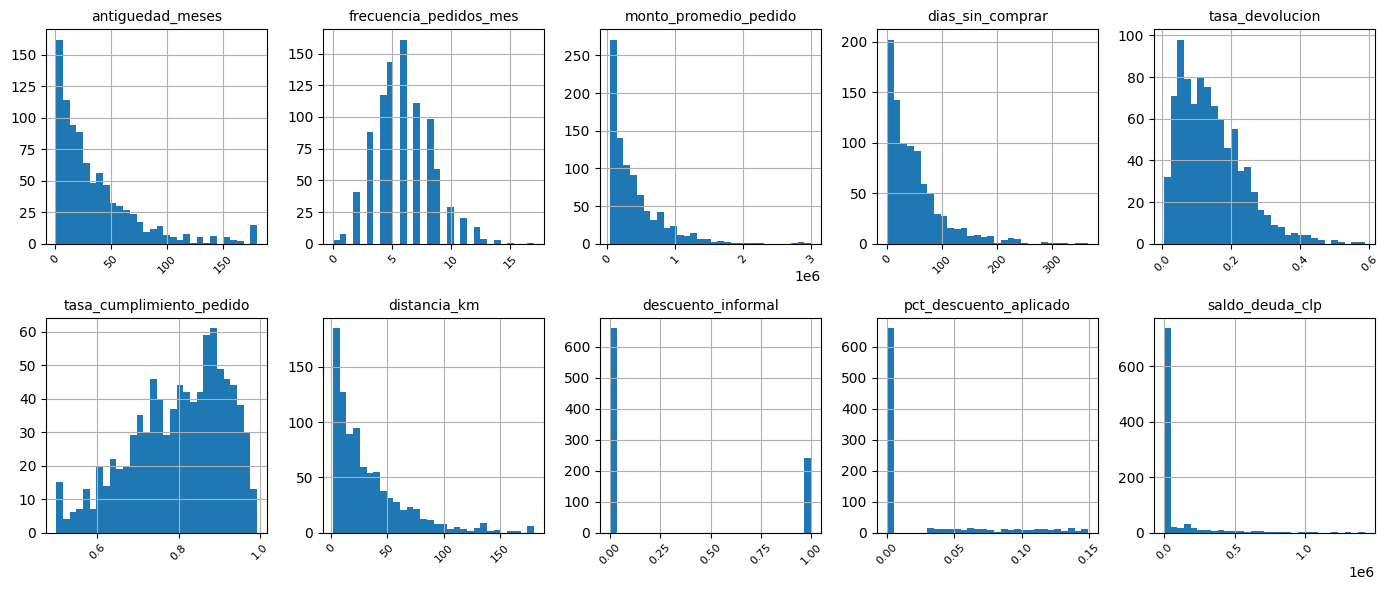


--- Detección de Outliers ---
antiguedad_meses             49
frecuencia_pedidos_mes        2
monto_promedio_pedido        46
dias_sin_comprar             54
tasa_devolucion              18
tasa_cumplimiento_pedido      0
distancia_km                 40
descuento_informal            0
pct_descuento_aplicado      124
saldo_deuda_clp             182
dtype: int64


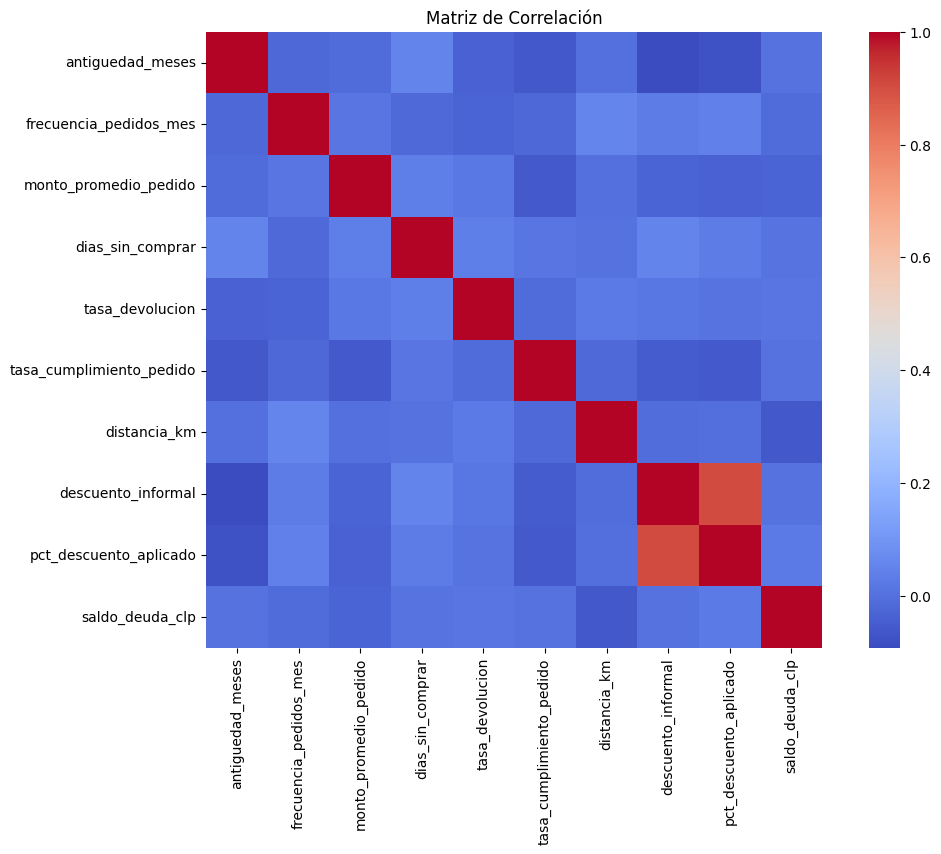

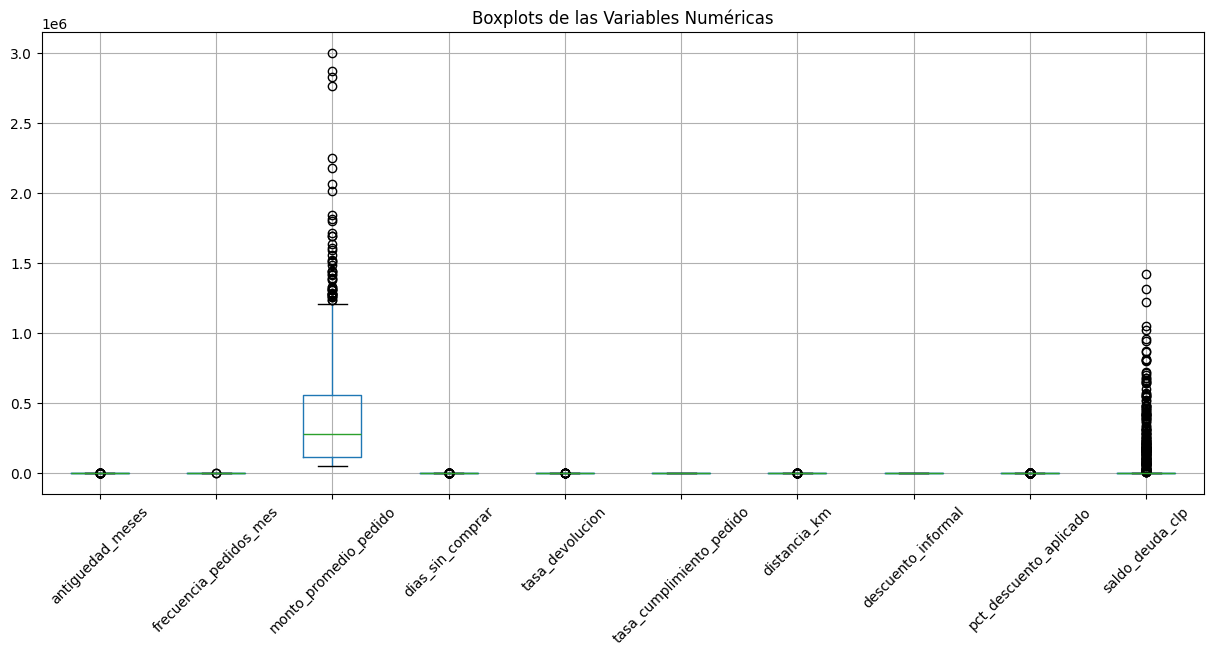

In [3]:
# Análisis Exploratorio (EDA)

# Obtener solo columnas numéricas (sin la variable objetivo)
numeric_cols = df.select_dtypes(include=np.number).drop(columns=['abandono']).columns.tolist()
print(f"Total de columnas numéricas: {len(numeric_cols)}")

# Distribuciones de variables (limitar a las primeras 10 columnas por rendimiento)
if numeric_cols:
    plt.figure(figsize=(14, 6))
    for i, col in enumerate(numeric_cols[:10]):
        plt.subplot(2, 5, i+1)
        df[col].hist(bins=30)
        plt.title(col, fontsize=10)
        plt.xticks(rotation=45, fontsize=8)
    plt.tight_layout()
    plt.show()

# Detección de outliers usando IQR
Q1 = df[numeric_cols].quantile(0.25)  # Calcular el primer cuartil (Q1)
Q3 = df[numeric_cols].quantile(0.75)  # Calcular el tercer cuartil (Q3)
IQR = Q3 - Q1  # Calcular el rango intercuartilico

outliers = ((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))).sum()  # Identificar outliers
print("\n--- Detección de Outliers ---")  # Mostrar la cantidad de outliers por columna
print(outliers)

# Matriz de correlación (solo para primeras columnas si hay muchas)
cols_to_correlate = numeric_cols[:15] if len(numeric_cols) > 15 else numeric_cols
plt.figure(figsize=(12, 8))
sns.heatmap(df[cols_to_correlate].corr(), cmap='coolwarm', cbar=True, square=True)  # Mostrar matriz de correlación
plt.title('Matriz de Correlación')
plt.show()

# Boxplots para visualizar las distribuciones (primeras 10 columnas)
if numeric_cols:
    plt.figure(figsize=(15, 6))
    df[numeric_cols[:10]].boxplot()  # Mostrar boxplots de las primeras 10 variables numéricas
    plt.title('Boxplots de las Variables Numéricas')
    plt.xticks(rotation=45)
    plt.show()